In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

2026-03-26 12:15:38.527048: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-26 12:15:38.979775: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-26 12:15:40.505162: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
data_dir = '/home/dhvani-cygner/Downloads/archive (1)/PetImages'

In [3]:
from PIL import Image

def remove_corrupt_images(path):
    for folder in ["Cat", "Dog"]:
        folder_path = os.path.join(path, folder)
        for file in os.listdir(folder_path):
            file_path = os.path.join(folder_path, file)
            try:
                img = Image.open(file_path)
                img.verify()
            except:
                os.remove(file_path)

remove_corrupt_images(data_dir)
print("Corrupted images removed")

/home/dhvani-cygner/Downloads/Cygner Task/image processing/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Corrupted images removed


In [4]:
img_size = (150, 150)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,   
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [5]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D(2,2))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))

model.add(layers.Dense(1, activation='sigmoid'))  

/home/dhvani-cygner/Downloads/Cygner Task/image processing/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-26 12:20:23.957074: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [6]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [8]:
history = model.fit(train_data,epochs=10,validation_data=val_data)

Epoch 1/10
276/625 ━━━━━━━━━━━━━━━━━━━━ 3:03 525ms/step - accuracy: 0.5534 - loss: 0.6836

/home/dhvani-cygner/Downloads/Cygner Task/image processing/.venv/lib/python3.12/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


625/625 ━━━━━━━━━━━━━━━━━━━━ 352s 563ms/step - accuracy: 0.6127 - loss: 0.6534 - val_accuracy: 0.6795 - val_loss: 0.5957
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 343s 548ms/step - accuracy: 0.7004 - loss: 0.5760 - val_accuracy: 0.7647 - val_loss: 0.4979
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 352s 563ms/step - accuracy: 0.7536 - loss: 0.5074 - val_accuracy: 0.7827 - val_loss: 0.4628
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 353s 565ms/step - accuracy: 0.7834 - loss: 0.4639 - val_accuracy: 0.8075 - val_loss: 0.4195
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 347s 556ms/step - accuracy: 0.8055 - loss: 0.4286 - val_accuracy: 0.8153 - val_loss: 0.4109
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 332s 531ms/step - accuracy: 0.8148 - loss: 0.4095 - val_accuracy: 0.8407 - val_loss: 0.3689
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 314s 502ms/step - accuracy: 0.8340 - loss: 0.3811 - val_accuracy: 0.8435 - val_loss: 0.3497
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 313s 501ms/step - accuracy: 0.8421 - loss: 0.36

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Dog


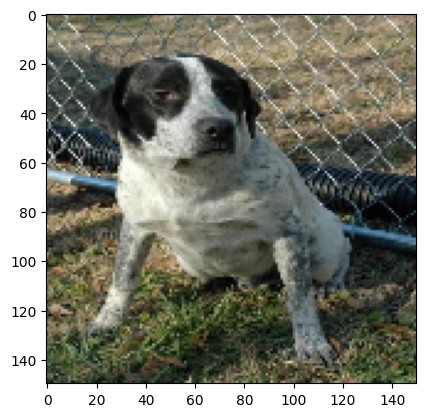

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = "/home/dhvani-cygner/Downloads/archive (1)/PetImages/Dog/63.jpg"  

img = image.load_img(img_path, target_size=(150,150))
plt.imshow(img)
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)


result = model.predict(img_array)
print('' if result >= 0.5 else 'CAT')
